# **Predicting Student Academic Performance and Identifying Key Success Factors**

# **I. Introduction**

**Name**  : Clarence Manzo

**Objectives**:
- Perform data preprocessing or feature engineering to prepare high-quality inputs for regression models
- Develop models using KNN, SVM, Decision Tree, Random Forest, and Boosting algorithms with pipeline
- To analyze and identify how each factors influence students’ final academic performance
- Estimate students’ final grades from various factors

**Problem**:  
Educational institutions struggle to identify which students are likely to underperform before final exam results are known. Inefficient identification of “at-risk” students leads to higher failure rates. Because academic outcomes are influenced by diverse factors, a predictive model is needed to understand how these factors influence final performance. It will help decision-making and early intervention in schools and higher education institutions.

**Users**:  
Educators, School Administrators, Parents, and Students

**Dataset**:  
This dataset is from two publicly available secondary school datasets, which are mathematics course performance and portuguese language course performance. The dataset contains demographic, social, behavioral, and academic attributes of each student.  
*URL: https://archive.ics.uci.edu/dataset/320/student+performance*  

# **II. Import Libraries**

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from feature_engine.outliers import Winsorizer
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

# Pipeline & Model libraries
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Training libraries
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Model Metrics libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# **III. Data Loading**

In [2]:
# Load math performance dataset to a dataframe
df_mat = pd.read_csv("student-mat.csv", sep=";", quotechar='"')

# View first 10 records
df_mat.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [3]:
# Load portuguese language performance dataset to a dataframe
df_por = pd.read_csv("student-por.csv", sep=";", quotechar='"')

# View first 10 records
df_por.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [4]:
# Combine dataframes and view first 10 records
df = pd.concat([df_mat, df_por], ignore_index=True)
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [5]:
# Check dataset's rows and columns
df.shape

(1044, 33)

There's a total of **1044 records** of students with **33 columns/attributes**.

In [6]:
# Show the data types from each column
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Every columns already have the correct data type.

In [7]:
# Show the summary of numerical data distribution
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


- The average age is 16.7 years with most students between 16 and 18. 
- Study time has an average of 2 (2–5 hours/week), which mean most students study relatively low.  
- The majority of students have no prior failures. 
- Over half of students spend less than 15 minutes travel times to school.
- Free time and hang out time is averaging at 3, which indicates a balanced leisure life.
- Family relationships are generally positive averaging at 4.
- Absences are right-skewed with the median of 2 with maximum at 75, indicating a small group of students have extremely high absence.
- Alcohol consumption is low on weekdays (average at 1.5) and moderate on weekends (average at 2.3).
- Health status is averaging at 3.5 which is generally good.
- Average grades for G1, G2, and G3 are all similars, and have greater dispersion in final outcomes as standard deviation increases toward G3. 

In [8]:
# Print column's name
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

The columns' name are already up to standard, so any further formatting/renaming is not needed.

In [9]:
# Check duplicate rows
print(df.duplicated().sum())

0


There is no duplicated data in this dataset, so handling duplicated data is not needed.

# **IV. Exploratory Data Analysis (EDA)**

## 1. Does study time significantly impact students’ final performance?

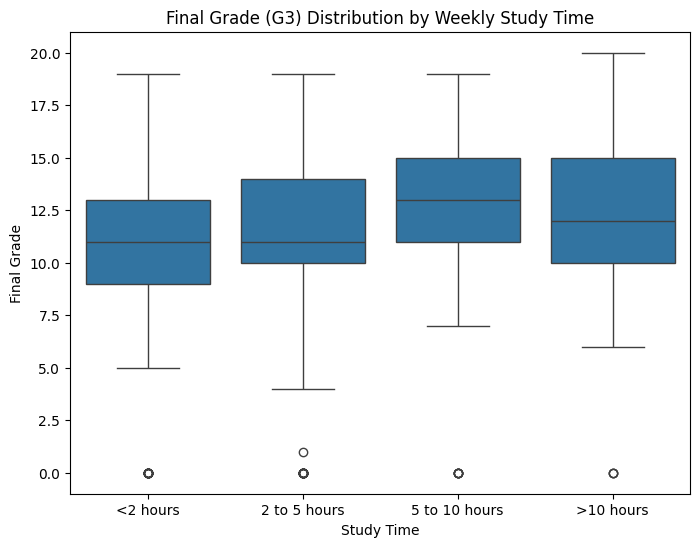

In [10]:
# Plot boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="studytime", y="G3")
plt.title("Final Grade (G3) Distribution by Weekly Study Time")
plt.xticks([0,1,2,3],["<2 hours", "2 to 5 hours", "5 to 10 hours", ">10 hours"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

It shows that students who dedicate more weekly study time achieve higher final grades, with the strongest performance observed in the 5–10 hour range. However, the highest study-time group resulting decreases in final grades. The wide overlap across categories indicates that study time alone does not determine academic success and should be analyzed alongside other factors.

## 2. How does absence affect final academic performance?

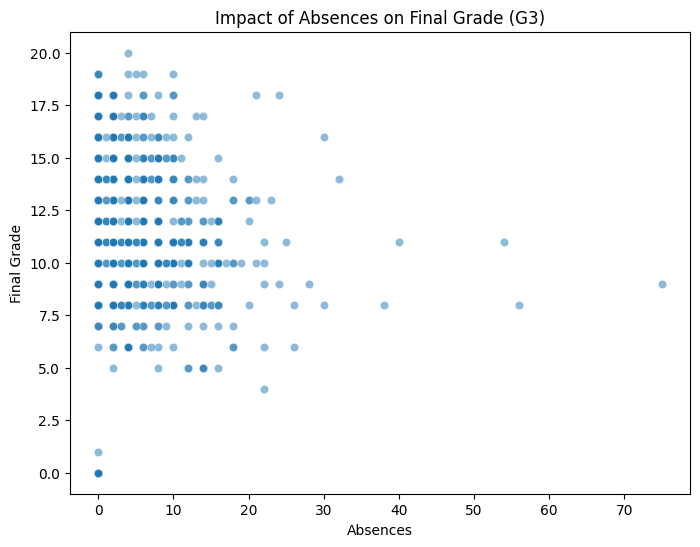

In [11]:
# Plot scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="absences", y="G3", alpha=0.5)
plt.title("Impact of Absences on Final Grade (G3)")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.show()

The scatterplot reveals that low absence does not guarantee high performance and high absence almost guarantees poor outcomes. This shows that attendance is quiete an influential predictor of student's final grade.

## 3. Do students with past academic failures perform worse in the final exam?

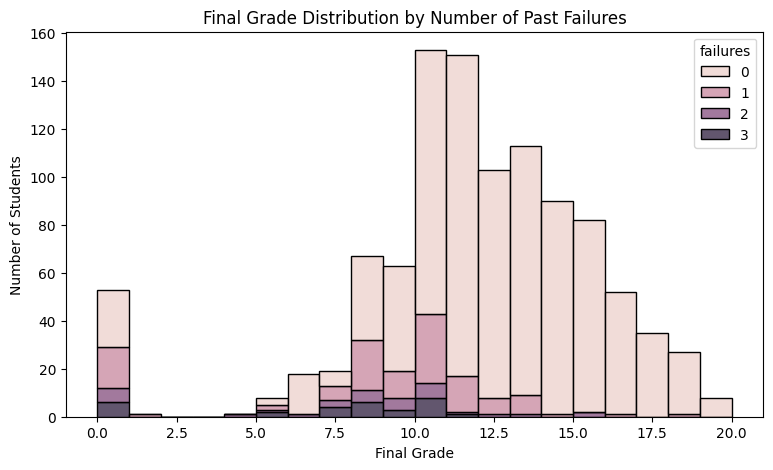

In [12]:
# Plot stacked histrogram
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="G3", hue="failures", bins=20, multiple="stack")
plt.title("Final Grade Distribution by Number of Past Failures")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

The histogram reveals that students without prior failures consistently achieve higher and more variable final grades, while students with multiple failures have lower final grades. This indicates that past failures is a critical feature for predicting student's performance.

## 4. How do social activity levels relate to academic outcomes?

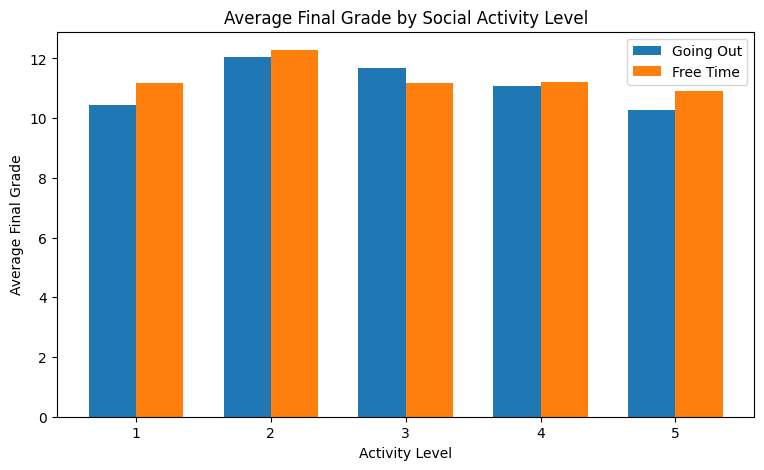

In [13]:
# Average final grade by each social activity category
goout_mean = df.groupby("goout")["G3"].mean()
freetime_mean = df.groupby("freetime")["G3"].mean()

# Ensure same x-axis levels (1–5) and get the value from each level
levels = sorted(set(goout_mean.index).union(freetime_mean.index))
goout_vals = [goout_mean.get(l, np.nan) for l in levels]
freetime_vals = [freetime_mean.get(l, np.nan) for l in levels]

x = np.arange(len(levels))

# Plot the grouped bar chart
plt.figure(figsize=(9,5))
plt.bar(x - 0.35/2, goout_vals, 0.35, label="Going Out")
plt.bar(x + 0.35/2, freetime_vals, 0.35, label="Free Time")
plt.xticks(x, levels)
plt.xlabel("Activity Level")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Social Activity Level")
plt.legend()
plt.show()

Students with moderate levels of going-out and free-time achieve higher final grades in average. However, excessive or minimal social activity makes students to achieve a lower final grade average. This conclude that balance is key for achieving higher student's performance rather than restriction.

## 5. Do parents' education level affects students academic performance?

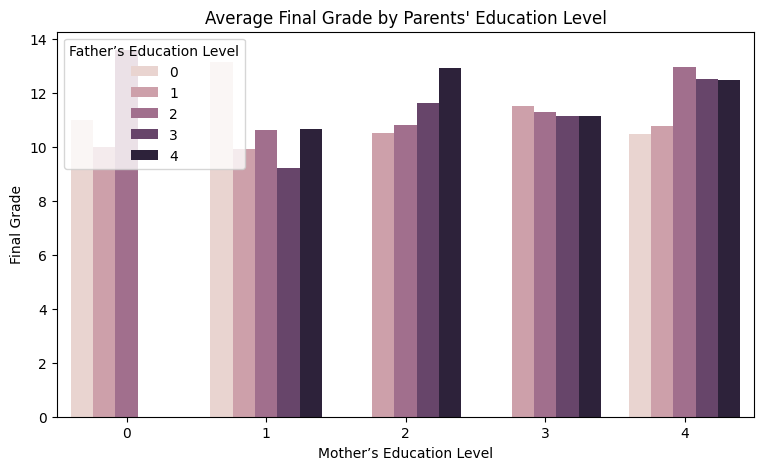

In [14]:
# Average final grade by mother's and father's education level
edu_means = df.groupby(["Medu", "Fedu"])["G3"].mean().reset_index()

# Plot the grouped bar chart
plt.figure(figsize=(9,5))
sns.barplot(data=edu_means, x="Medu", y="G3", hue="Fedu")
plt.title("Average Final Grade by Parents' Education Level")
plt.xlabel("Mother’s Education Level")
plt.ylabel("Final Grade")
plt.legend(title="Father’s Education Level")
plt.show()

The analysis shows that mother’s education level have a more consistent effect towards student's final grade. Father's education level improves student's performance when combined with higher mother's education level. These findings prove that parental educational background have a significant impact on student's academic performance.

## 6. Is there any academic performance difference between gender?

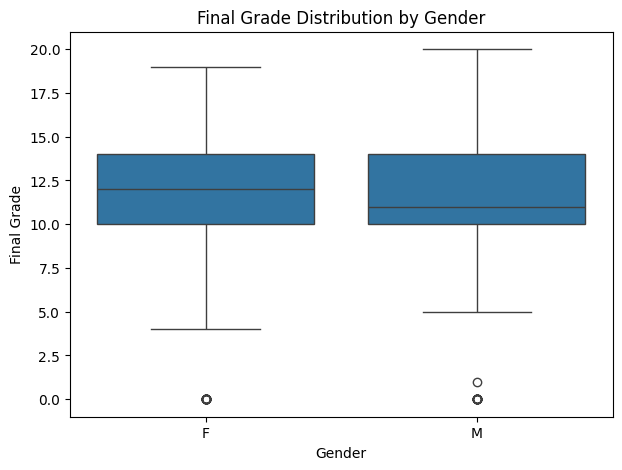

In [15]:
# Plot boxplots
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="sex", y="G3")
plt.title("Final Grade Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Final Grade")
plt.show()

The boxplot shows the median grade for females is slightly higher compared to males which indicates a typical performance for female students. Both gender spanning from approximately 10 to 14 which indicates that student's final grade is consistent across genders. Therefore, gender is not a significant predictor for student's performance.

## 7. Does the primary guardian influence students' academic performance?

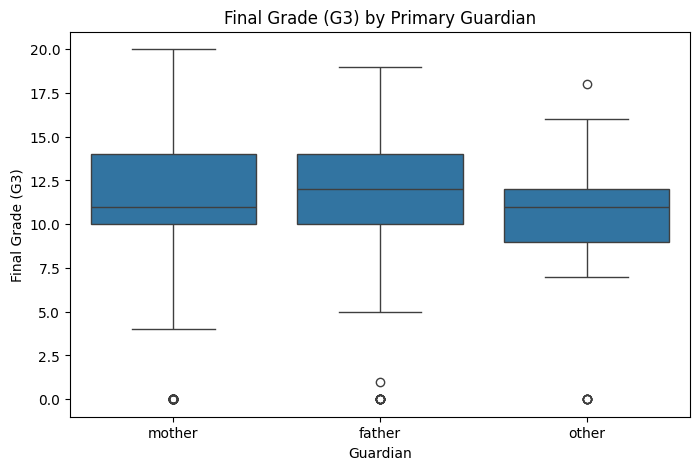

In [16]:
# Plot boxplots
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="guardian", y="G3")
plt.title("Final Grade (G3) by Primary Guardian")
plt.xlabel("Guardian")
plt.ylabel("Final Grade (G3)")
plt.show()

Students with a father as their primary guardian have the highest median final grade, while students with mother or other guardians show a slightly lower and identical median grade at around 11. All three categories have outliers at the bottom which tell that a small group of students is significantly underperforming regardless of the guardian.

# **V. Feature Engineering**

## 1. Cardinality Check

In [17]:
# Show the summary of object data distribution
df.describe(include='object')

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,772,591,759,738,923,399,584,430,728,925,640,824,528,835,955,827,673


The dataset contains only low to moderate (2-5) cardinality categorical features, making it safe for One-Hot Encoding and no dimensionality explosion will occur.

## 2. Split Dataset

In [18]:
# Define features and target
X = df.drop(columns=['G3'])
y = df['G3']

# Split dataset into 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Check train and test data sizes
print('Size Train Set : ', X_train.shape)
print('Size Test Set  : ', X_test.shape)

Size Train Set :  (730, 32)
Size Test Set  :  (314, 32)


## 3. Handle Outliers

In [19]:
# Get numerical columns
num_cols = list(X_train.select_dtypes(include='number').columns)

# Initialize list to store data
listItem = []

# Loop each column
for col in num_cols:
    # Calculate skewness
    skewness = round(X_train[col].skew(), 1)

    # Classify distribution
    distribution = np.where((skewness <= 0.5) & (skewness >= -0.5), 'normal', 'skewed')

    # Calculate upper boundary and lower boundary
    if distribution == 'skewed':
        IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
        low_bound = X_train[col].quantile(0.25) - (IQR * 3)
        up_bound = X_train[col].quantile(0.75) + (IQR * 3)
    else:
        low_bound = X_train[col].mean() - 3* X_train[col].std()
        up_bound = X_train[col].mean() + 3* X_train[col].std()

    # Calculate outlier percentage
    outlier_percent = ((len(X_train[X_train[col] > up_bound]) / len(X_train) * 100) + (len(X_train[X_train[col] < low_bound]) / len(X_train) * 100))
    
    # Input calculated variables into list
    listItem.append([col, skewness, distribution, round(low_bound,2), round(up_bound,2), round(outlier_percent,2)])

# Create and show the dataframe from the list data
outlier_distribution_df = pd.DataFrame(columns=['Column Name', 'Skewness', 'Distribution', 'Lower Boundary', 'Upper Boundary', 'Outlier Percentage'], data=listItem)
outlier_distribution_df

,Column Name,Skewness,Distribution,Lower Boundary,Upper Boundary,Outlier Percentage
0,age,0.4,normal,13.07,20.34,0.27
1,Medu,-0.2,normal,-0.72,6.02,0.00
2,Fedu,0.1,normal,-0.89,5.76,0.00
3,traveltime,1.4,skewed,-2.00,5.00,0.00
4,studytime,0.7,skewed,-2.00,5.00,0.00
5,failures,3.0,skewed,0.00,0.00,15.89
6,famrel,-1.0,skewed,1.00,8.00,0.00
7,freetime,-0.2,normal,0.09,6.30,0.00
8,goout,0.0,normal,-0.31,6.65,0.00
9,Dalc,2.1,skewed,-2.00,5.00,0.00


Most of the numerical features in this dataset doesn't have outliers. While *failures* feature has a very high outlier at almost 16% and is skewed, these outliers are informative and not noise because *failures* feature is a discrete count which makes them a meaningful extreme values.

The only value that should be handled is *absences* feature as it has 1.4% outlier, is highly skewed, and a continuous variable. Therefore **capping (Winsorization)** will be done to reduce the influence of outliers while preserving dataset size and structure without removing meaningful data. **Quantile-based** is chosen over IQR because the highly right-skewed and zero-inflated distribution. While IQR-based would excessively truncate valid outliers.

## 4. Handle Missing Values

In [20]:
# Check missing values both for X_train and X_test dataset
pd.concat([X_train.isnull().sum().rename('X_train'), X_test.isnull().sum().rename('X_test')], axis=1)

,X_train,X_test
school,0,0
sex,0,0
age,0,0
address,0,0
famsize,0,0
Pstatus,0,0
Medu,0,0
Fedu,0,0
Mjob,0,0
Fjob,0,0


This dataset doesn't have any missing values across all columns. Therefore, no missing values handling is needed.

## 5. Split Categorical & Numerical Columns

In [21]:
# Get numeric and categorical column
num_columns = X_train.select_dtypes(include = np.number).columns.tolist()
cat_columns = X_train.select_dtypes(include = ['object']).columns.tolist()

# Print the columns name
print('Numeric Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numeric Columns :  ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical Columns :  ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [22]:
# Split the X_train dataframe by numerical and categorical columns
X_train_num = X_train[num_columns]
X_train_cat = X_train[cat_columns]

# Split the X_test dataframe by numerical and categorical columns
X_test_num = X_test[num_columns]
X_test_cat = X_test[cat_columns]

# Check the X_train numerical dataframe
X_train_num

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
447,15,4,2,2,1,0,5,5,5,3,4,5,4,10,9
694,20,2,1,2,2,0,1,2,3,1,2,2,8,10,12
448,15,4,4,1,1,0,3,3,4,2,3,5,0,13,12
934,16,4,1,2,2,0,1,2,4,2,2,1,8,9,10
582,16,1,3,1,2,0,4,3,5,1,1,3,0,14,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,15,4,2,1,3,0,5,3,3,1,3,1,4,13,14
330,18,2,2,1,4,0,4,5,5,2,4,5,2,9,8
466,15,4,2,1,4,0,3,3,3,1,1,3,0,11,9
121,15,2,2,1,4,0,5,5,4,1,2,5,6,16,14


In [23]:
# Check the X_train categorical dataframe
X_train_cat

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
447,GP,M,U,LE3,A,health,health,other,father,no,no,no,no,yes,yes,no,no
694,GP,F,R,GT3,T,other,other,course,other,no,yes,yes,yes,yes,no,yes,yes
448,GP,F,U,GT3,T,services,services,course,mother,yes,yes,no,no,yes,yes,yes,no
934,MS,F,U,LE3,T,other,other,home,mother,no,yes,no,yes,yes,yes,yes,no
582,GP,F,U,GT3,T,at_home,services,home,mother,no,no,no,yes,no,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,GP,F,U,GT3,T,other,other,reputation,mother,no,yes,no,yes,yes,yes,yes,no
330,GP,M,U,LE3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
466,GP,M,U,GT3,T,other,other,course,mother,no,no,no,no,yes,yes,yes,no
121,GP,M,U,GT3,T,services,services,home,father,no,yes,yes,yes,yes,yes,yes,no


## 6. Feature Selection

Spearman will be used to estimate numerical features correlation since the data are partially skewed & have several outliers, and the target variable is numerical.

In [24]:
# Feature selection for numerical columns
cols = [] # List of column name
p_values = [] # List of p-values
corr_values = [] # List of correlation values
interpretations = [] # List of  interpretations

# Loop each column from numerical columns of training data  
for col in X_train_num.columns:
    corr_coef, p_value = spearmanr(X_train_num[col], y_train, nan_policy='omit')

    # Store column name and results
    cols.append(col)
    p_values.append(p_value)
    corr_values.append(corr_coef)

    # Interpret result
    if p_value < 0.05:
        interpretations.append('Correlated')
    else :
        interpretations.append('No Correlation')

# Create dataframe for a better view
pd.DataFrame({'Column Name':cols, 'P Values': p_values, 'Correlation Value': corr_values, 'Result': interpretations})

,Column Name,P Values,Correlation Value,Result
0,age,3.643548e-02,-0.077446,Correlated
1,Medu,5.719484e-11,0.239337,Correlated
2,Fedu,6.848876e-08,0.198040,Correlated
3,traveltime,1.566704e-04,-0.139468,Correlated
4,studytime,3.145561e-08,0.203002,Correlated
5,failures,9.208351e-31,-0.408701,Correlated
6,famrel,1.966957e-01,0.047838,No Correlation
7,freetime,7.794667e-03,-0.098411,Correlated
8,goout,9.354588e-03,-0.096128,Correlated
9,Dalc,1.062290e-05,-0.162200,Correlated


Almost all numerical features show a relationship with the final grade (G3). Only *famrel* feature shows no correlation against the target variable, thus this feature will be removed from the dataset.

In [25]:
# Remove famrel feature from dataset
X_train_num.drop(['famrel'], inplace=True, axis=1)
X_test_num.drop(['famrel'], inplace=True, axis=1)

C:\Users\Acer\AppData\Local\Temp\ipykernel_19232\3785163307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_num.drop(['famrel'], inplace=True, axis=1)
C:\Users\Acer\AppData\Local\Temp\ipykernel_19232\3785163307.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_num.drop(['famrel'], inplace=True, axis=1)


Categorical predictors are assessed using ANOVA F-tests because the target variable is numerical.

In [26]:
# Feature selection for categorical columns
cols = [] # List of column name
p_values = [] # List of p-values
f_stats = [] # List of f-statistics
interpretations = [] # List of  interpretations

# Loop each column from categorical columns of training data  
for col in X_train_cat.columns:
    F_stat, p_value = f_oneway(*[y_train[X_train_cat[col] == category] for category in X_train_cat[col].dropna().unique()])

    # Store column name and results
    cols.append(col)
    p_values.append(p_value)
    f_stats.append(F_stat)

    # Interpret result
    if p_value < 0.05:
        interpretations.append('Correlated')
    else :
        interpretations.append('No Correlation')

# Create dataframe for a better view      
pd.DataFrame({'Column Name':cols, 'P Values': p_values, 'F-statistics': f_stats, 'Result': interpretations})

,Column Name,P Values,F-statistics,Result
0,school,1.285452e-04,14.821922,Correlated
1,sex,1.341564e-01,2.248744,No Correlation
2,address,1.596312e-04,14.405510,Correlated
3,famsize,5.227689e-02,3.779248,No Correlation
4,Pstatus,9.462207e-01,0.004553,No Correlation
5,Mjob,2.113242e-04,5.546766,Correlated
6,Fjob,1.817863e-01,1.565085,No Correlation
7,reason,2.261450e-03,4.890094,Correlated
8,guardian,5.001507e-01,0.693507,No Correlation
9,schoolsup,2.622205e-02,4.961541,Correlated


Categorical features such as *sex*, *famsize*, *Pstatus*, *Fjob*, *guardian*, *famsup*, *paid*, *activities*, and *nursery* have no correlation against the student's final grade (G3), therefore these features will be removed from the dataset.

In [27]:
# Remove uncorrelated features from dataset
X_train_cat.drop(['sex', 'famsize', 'Pstatus', 'Fjob', 'guardian', 'famsup', 'paid', 'activities', 'nursery'], inplace=True, axis=1)
X_test_cat.drop(['sex', 'famsize', 'Pstatus', 'Fjob', 'guardian', 'famsup', 'paid', 'activities', 'nursery'], inplace=True, axis=1)

C:\Users\Acer\AppData\Local\Temp\ipykernel_19232\1539932425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_cat.drop(['sex', 'famsize', 'Pstatus', 'Fjob', 'guardian', 'famsup', 'paid', 'activities', 'nursery'], inplace=True, axis=1)
C:\Users\Acer\AppData\Local\Temp\ipykernel_19232\1539932425.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_cat.drop(['sex', 'famsize', 'Pstatus', 'Fjob', 'guardian', 'famsup', 'paid', 'activities', 'nursery'], inplace=True, axis=1)


## 7. Feature Scaling

Min–max scaler will be used because the numerical predictors are already bounded and partially ordinal. As the data will be capped using winsorizer, outlier sensitivity is no longer a risk.

## 8. Feature Encoding

One-hot encoding will be used because the categorical predictors have low cardinality. While Label Encoding is incorrect because it makes an ordinal relationship which imposes fake order.

## 9. Concate Categorical & Numerical Columns

In [28]:
# Merge the numerical and categorical dataset in a dataframe
X_train_merged = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_merged = pd.concat([X_test_num, X_test_cat], axis=1)

In [29]:
# Display the merged training dataset
X_train_merged.head(5)

,age,Medu,Fedu,traveltime,studytime,failures,freetime,goout,Dalc,Walc,...,G1,G2,school,address,Mjob,reason,schoolsup,higher,internet,romantic
447,15,4,2,2,1,0,5,5,3,4,...,10,9,GP,U,health,other,no,yes,no,no
694,20,2,1,2,2,0,2,3,1,2,...,10,12,GP,R,other,course,no,no,yes,yes
448,15,4,4,1,1,0,3,4,2,3,...,13,12,GP,U,services,course,yes,yes,yes,no
934,16,4,1,2,2,0,2,4,2,2,...,9,10,MS,U,other,home,no,yes,yes,no
582,16,1,3,1,2,0,3,5,1,1,...,14,13,GP,U,at_home,home,no,yes,yes,yes


In [30]:
# Display the merged testing dataset
X_test_merged.head(5)

,age,Medu,Fedu,traveltime,studytime,failures,freetime,goout,Dalc,Walc,...,G1,G2,school,address,Mjob,reason,schoolsup,higher,internet,romantic
971,18,3,2,2,1,0,5,5,5,5,...,9,10,MS,R,other,course,no,yes,yes,no
280,17,4,1,2,1,0,5,4,2,4,...,8,8,GP,U,services,home,no,yes,yes,yes
536,16,1,1,4,2,0,1,3,1,1,...,14,13,GP,R,at_home,course,no,yes,no,no
824,16,4,4,1,2,0,3,2,1,3,...,10,11,MS,R,at_home,home,no,yes,no,no
644,16,3,2,2,3,0,3,3,1,3,...,12,12,GP,U,at_home,reputation,no,yes,yes,yes


## 10. Feature Transformation Pipeline

In [31]:
# Get the updated numeric and categorical columns
num_columns = X_train_merged.select_dtypes(include = np.number).columns.tolist()
cat_columns = X_train_merged.select_dtypes(include = ['object']).columns.tolist()

# Create pipeline for numerical features transformation
num_pipeline = Pipeline([
    ('winsorizer', Winsorizer(capping_method='quantiles', tail='right', fold=0.01, variables=['absences'], missing_values='ignore')),
    ('scaler', MinMaxScaler())
])

# Create pipeline for categorical features transformation
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Create column transformer from both created pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_columns),
        ('cat', cat_pipeline, cat_columns)
    ],
    remainder='drop'
)

# **VI. Model Definition**

All the models will be evaluated using multiple metrics to provides a balanced evaluation. The evaluation metrics are:  
- MAE (Mean Absolute Error) will be used for interpretability and robustness to outliers.
- RMSE (Root Mean Squared Error) will be used to measures prediction stability.
- MAPE (Mean Absolute Percentage Error) is used to provide an interpretable relative error metric, complementing absolute and squared error measures.
- R² Score will be used to measures the proportion of variance explained by the model.

All regression models are initially trained using default hyperparameters to establish a fair and unbiased baseline comparison across algorithms. Hyperparameter tuning will be done after the best model with default hyperparameters is selected.

KNN used a distance-based baseline model to capture local patterns in the data. It performs well after feature scaling and evaluate whether students with similar characteristics tend to have similar final grades.

In [32]:
# Define KNN Model using pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

SVM is used to model non-linear relationships. It is effective in high dimensional spaces and great for comparison against tree-based models.

In [33]:
# Define SVM Model using pipeline
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

Decision Tree will be used to model non-linear features.

In [34]:
# Define Decision Tree Model using pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

Random Forest is used to reduce overfitting by aggregating multiple decision trees to improve prediction and capture more complex interactions across features.

In [35]:
# Define Random Forest Model using pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

Gradient Boosting is used because it can correct previous prediction errors to achieve higher accuracy. As it's a structured tabular data, this algorithm is very effective.

In [36]:
# Define Gradient Boost Model using pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])

In [37]:
# Store all defined models with pipeline together
models = {
    'KNN': knn_pipeline,
    'SVM': svm_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline
}

# **VII. Model Training**

In [38]:
# Define the scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAPE': 'neg_mean_absolute_percentage_error',
    'R2': 'r2'
}

In [39]:
# Define empty list to store training results
cv_results = []

# Loop each pipeline model and run cross validation
for model_name, pipeline in models.items():
    scores = cross_validate(pipeline, X_train_merged, y_train, cv=5, scoring=scoring, n_jobs=-1)

    cv_results.append({
        'Model': model_name,
        'MAE': -scores['test_MAE'].mean(),
        'RMSE': -scores['test_RMSE'].mean(),
        'MAPE': -scores['test_MAPE'].mean(),
        'R2': scores['test_R2'].mean()
    })

# Convert results to DataFrame
cv_results_df = pd.DataFrame(cv_results).sort_values(by='RMSE')
cv_results_df

,Model,MAE,RMSE,MAPE,R2
4,Gradient Boosting,0.897173,1.415540,6.743716e+14,0.857848
3,Random Forest,0.931055,1.483625,6.884955e+14,0.844630
2,Decision Tree,1.193151,2.154119,4.750372e+14,0.681560
1,SVM,1.588418,2.492397,2.055471e+15,0.575568
0,KNN,2.530137,3.486784,2.345573e+15,0.165090


Extremely large MAPE values indicates presence of zero or near-zero target values, thus making MAPE not reliable in this case. KNN and SVM performs really bad as it doesn't captured well on complex feature interactions. The Decision Tree is overfitting since it has high RMSE and low R².

**Gradient Boosting Regressor have the best performance** with the lowest prediction error and highest explained variance (R²). Therefore, it is selected as the final model for hyperparameter tuning.

In [40]:
# Define the hyperparameters to be tuned
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_leaf': [1, 5, 10],
    'model__subsample': [0.8, 1.0]
}

- n_estimators: the number of trees used in the ensemble.
- learning_rate: the contribution of each tree to the final prediction.
- max_depth: the maximum depth of each trees.
- min_samples_leaf: the minimum samples required in a leaf node.
- subsample: the fraction of samples used to train each tree.

These hyperparameters are chosen because they control bias–variance tradeoff and have the largest impact on Gradient Boosting performance.

GridSearchCV will be used as it evaluates all possible combinations of hyperparameters. This guarantees that the selected configuration is the best-performing within all possible combinations.

In [41]:
# Initialzie grid search CV
grid_search = GridSearchCV(gb_pipeline, param_grid=param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV
grid_search.fit(X_train_merged, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer(capping_method='quantiles',
                                                                                                     fold=0.01,
                                                                                                     missing_values='ignore',
                                                                                                     variables=['absences'])),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['age',
                                                                          'Medu',
                                                                          'Fedu',
                                                                          'traveltime',
                                                                          'studytime',
                                                                          'failures',
                                                                          'freetime',
                                                                          'goout',
                                                                          'Dalc',
                                                                          'Walc',
                                                                          'healt...
                                                                          'address',
                                                                          'Mjob',
                                                                          'reason',
                                                                          'schoolsup',
                                                                          'higher',
                                                                          'internet',
                                                                          'romantic'])])),
                                       ('model', GradientBoostingRegressor())]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1, 0.2],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_leaf': [1, 5, 10],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [42]:
# Print the RMSE and the parameter from the best Gradient Boosting Regressor
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best RMSE: 1.3752805401378076
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}


The best RMSE is 1.38 which is lower than the cross-validation baseline. So, hyperparameter tuning has successfully improved the model's generalization.

Best hyperparameters:  
- learning rate: 0.05
- max_depth: 3
- min_samples_leaf: 5
- n_estimators: 100
- subsample: 0.8

In [43]:
# Save the best model
best_model = grid_search.best_estimator_

# **VIII. Model Evaluation**

In [44]:
# Train the gradient boosting model before hyperparameter tuning
gb_pipeline.fit(X_train_merged, y_train)

# Predict on test dataset using the gradient boosting model before hyperparameter tuning
y_pred = gb_pipeline.predict(X_test_merged)

# Print the gradient boosting model before hyperparameter tuning scoring metrics
print("BEFORE HYPERPARAMETER TUNING")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

BEFORE HYPERPARAMETER TUNING
MAE : 0.9449942722100392
RMSE: 1.680774202498888
MAPE: 919987366842380.2
R2  : 0.8095895775226837


In [45]:
# Predict on test dataset using the best model
y_pred = best_model.predict(X_test_merged)

# Print the best model's scoring metrics
print("AFTER HYPERPARAMETER TUNING")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

AFTER HYPERPARAMETER TUNING
MAE : 0.9062991953875259
RMSE: 1.6208651254441682
MAPE: 905355134333459.4
R2  : 0.8229215444431117


Gradient Boosting Regressor comparison before and after hyperparameter tuning:  
- Lower Average Error: MAE decreased from 0.945 to 0.906, meaning the model's predictions are 0.04 points closer to the actual grades.
- Reduced Large Deviations: RMSE dropped from 1.68 to 1.62. So, the tuned model is better at avoiding "big misses".
- Better Fit: R² increased from 0.810 to 0.823 means that the tuned model has a solid increase in predictive power.

The tuned model has high prediction accuracy from the MAE score. However, RMSE is higher than MAE which implies the presence of some larger prediction errors. But, the overall performance is stable as the magnitude remains reasonable. The tuned model has a strong generalization ability on unseen data as it explains 82% of the variance in the target variable. MAPE should not be used for interpretation in this case since there are zero or near-zero values in the target variable.

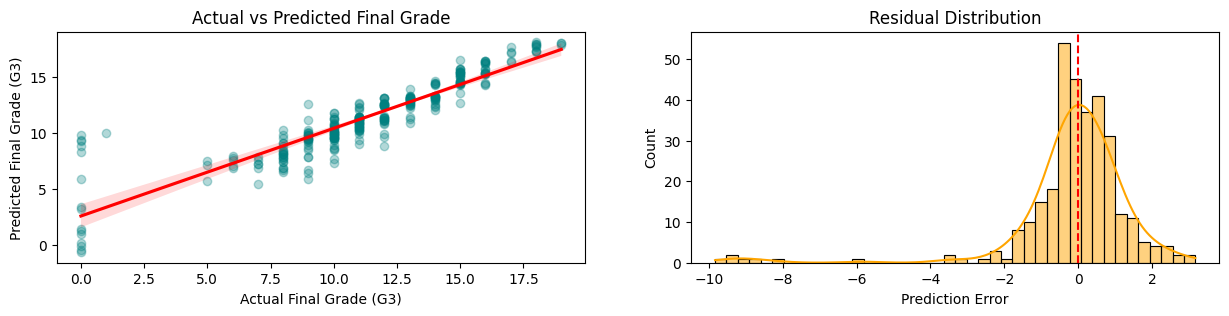

In [46]:
plt.figure(figsize=(15, 3))

# Plot actual and predicted target variable
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Actual vs Predicted Final Grade')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade (G3)')

# Plot the residual distribution
plt.subplot(1, 2, 2)
sns.histplot(y_test - y_pred, kde=True, color='orange')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution')
plt.xlabel('Prediction Error')
plt.show()

The scatterplot shows that the model has successfully captured the underlying patterns in the student dataset. The prediction accuracy is high for students scoring between 10 and 20 as the variance (shaded area around the red line) is minimal.

From the residual plot, the long left tail (errors between -10 and -4) are likely students who dropped out or missed the final exam, making it harder for the model to predict.

Given the complexity of student data, the Gradient Boosting Regressor is a great predictive model as it effectively handles the non-linear relationships that simpler models like KNN or Decision Trees might miss.

**Advantages**:
- High predictive accuracy as the model has R2 of 0.821.
- Robust to non-linearity because Gradient Boosting captures complex relationships between student's features with the final grade.
- Unbiased predictions as the residual distribution is tightly centered around 0, indicating that the model does not over-predict or under-predict for the general student population.

**Disadvantages**:
- Sensitive to outliers as the model has high errors when predicting scores between 5 and 10 for students who actually failed.

**Improvements**:  
- Implement a two-stage modeling approach. First, use a classifier to predict if a student will score 0. Then, use the current gradient boosting regressor only for students predicted to have a non-zero score.
- Instead of using MAPE, switch to Weighted Mean Absolute Percentage Error (WMAPE) or Mean Absolute Scaled Error (MASE) for more robust when dealing with zero-valued targets.
- As the model shows slight compression at the highest grade levels, adjust the loss function of the Gradient Boosting Regressor to make it more sensitive to the extremes values.

# **IX. Model Saving**

In [47]:
# Save the best Gradient Boosting Regressor Model after hyperparameter tuning
pickle.dump(best_model, open('gb_pipeline.pkl', 'wb'))

# **X. Conclusion**

To achieve a high quality data for the regression model, the outliers are handled using capping (winsorizer) with quantile method, selected features using Spearman & ANOVA F-Tests, scaled using Min-Max scaler, and encoded using One Hot Encoding. Among KNN, SVM, Decision Tree, Random Forest, and Gradient Boosting algorithms, the best algorithm is Gradient Boosting as it achieves the best performance with the lowest prediction error and highest explained variance (R²).

After hyperparameter tuning the Gradient Boosting model using GridSearchCV, the best hyperparameters are learning_rate: 0.05, max_depth: 4, min_samples_leaf: 10, n_estimators: 100, subsample: 0.8. The best model achieved MAE of 0.91, RMSE of 1.63, and R² of 0.82.

The analysis shows that study time, attendance rate, social activities such as going-out and free-time frequency, past failures, and parent's educational background have significant impacts towards student's performance or final grade (G3). While gender and guardian of the student don't influence their final academic performance.

From doing the model inference, the hyperparameter-tuned gradient boosting regressor model is successful in estimating final grade for new students.